In [ ]:
# ==================================================
# IMPORT LIBRARY
# ==================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# --- KUNCI SEMUA RANDOM SEED ---
SEED = 42
os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed dikunci:", SEED)

Seed dikunci: 42


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'genz_financial_dataset_v3.csv', 'lstm_model_best.keras', 'scaler_target.pkl', 'lstm_model_final.h5', 'genz_financial_dataset.csv', 'scaler.pkl', 'README_untuk_AI_Engineer.txt', 'laporan_teknis_genzCash.txt', 'le_user_type.pkl', 'lstm_dataset.csv', 'lstm_model_final.keras', 'rf_model.pkl', 'sample_data']


In [ ]:
df = pd.read_csv(
    '/content/genz_financial_dataset.csv'
)

DATA DICTIONARY

In [ ]:
data_dict = {
    'Kolom'      : ['User_ID', 'User_Type', 'Date', 'Category', 'Amount', 'Type', 'Year', 'Month', 'Day'],
    'Tipe Data'  : ['object', 'object', 'datetime64', 'object', 'int64', 'object', 'int64', 'int64', 'int64'],
    'Deskripsi'  : [
        'ID unik setiap pengguna (U001–U050)',
        'Kepribadian finansial: hemat, normal, boros, hustler, anak kos',
        'Tanggal transaksi (format YYYY-MM-DD)',
        'Kategori transaksi: makan, transport, belanja online, dst.',
        'Nominal transaksi dalam Rupiah (positif)',
        'Jenis transaksi: Income (pemasukan) atau Expense (pengeluaran)',
        'Tahun transaksi, diturunkan dari kolom Date',
        'Bulan transaksi (1–12), diturunkan dari Date',
        'Tanggal dalam bulan (1–31), diturunkan dari Date'
    ],
    'Contoh Nilai': ['U001', 'boros', '2025-03-14', 'makan', 35000, 'Expense', 2025, 3, 14]
}

dd_df = pd.DataFrame(data_dict)

print('\n' + '='*60)
print('DATA DICTIONARY')
print('='*60)
print(dd_df.to_string(index=False))


DATA DICTIONARY
    Kolom  Tipe Data                                                      Deskripsi Contoh Nilai
  User_ID     object                            ID unik setiap pengguna (U001–U050)         U001
User_Type     object Kepribadian finansial: hemat, normal, boros, hustler, anak kos        boros
     Date datetime64                          Tanggal transaksi (format YYYY-MM-DD)   2025-03-14
 Category     object     Kategori transaksi: makan, transport, belanja online, dst.        makan
   Amount      int64                       Nominal transaksi dalam Rupiah (positif)        35000
     Type     object Jenis transaksi: Income (pemasukan) atau Expense (pengeluaran)      Expense
     Year      int64                    Tahun transaksi, diturunkan dari kolom Date         2025
    Month      int64                   Bulan transaksi (1–12), diturunkan dari Date            3
      Day      int64               Tanggal dalam bulan (1–31), diturunkan dari Date           14


DEFINISI PERTANYAAN BISNIS

BQ1: Bagaimana merancang sistem pencatatan keuangan yang mudah
     digunakan sehingga pengguna mau konsisten mencatat transaksi?
→ Dianalisis melalui pola frekuensi transaksi per user type, kategori yang paling sering dicatat, dan konsistensi pencatatan bulanan antar kepribadian finansial.

BQ2: Bagaimana menyajikan data keuangan dalam bentuk yang sederhana
     namun informatif?
→ Dianalisis melalui visualisasi distribusi pengeluaran per kategori, tren bulanan, perbandingan income vs expense, dan pola musiman (Ramadan, Harbolnas).

BQ3: Bagaimana analisis data sederhana dapat memberikan insight
     yang relevan bagi pengguna?
→ Dianalisis melalui A/B Testing (Mann-Whitney & Chi-Square), feature importance model, dan prediksi pengeluaran bulanan berbasis LSTM untuk rekomendasi personal.

CEK STRUKTUR DATA

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136234 entries, 0 to 136233
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User_ID            136234 non-null  object 
 1   Employment_Status  136234 non-null  object 
 2   User_Type          136234 non-null  object 
 3   Date               136234 non-null  object 
 4   Category           136234 non-null  object 
 5   Amount             136234 non-null  int64  
 6   Type               136234 non-null  object 
 7   Balance            136234 non-null  int64  
 8   Year               136234 non-null  int64  
 9   Month              136234 non-null  int64  
 10  Day                136234 non-null  int64  
 11  Weekday            136234 non-null  object 
 12  day_of_week        136234 non-null  int64  
 13  is_weekday         136234 non-null  int64  
 14  is_ramadan         136234 non-null  int64  
 15  is_harbolnas       136234 non-null  int64  
 16  am

CEK MISSING VALUE

In [ ]:
print(df.isnull().sum())

User_ID              0
Employment_Status    0
User_Type            0
Date                 0
Category             0
Amount               0
Type                 0
Balance              0
Year                 0
Month                0
Day                  0
Weekday              0
day_of_week          0
is_weekday           0
is_ramadan           0
is_harbolnas         0
amount_log           0
is_income            0
dtype: int64


CEK JUMLAH USER

In [ ]:
print(df['User_ID'].nunique())

100


CEK TIPE USER

In [ ]:
print(df['User_Type'].value_counts())

User_Type
hustler     43164
anak kos    27575
normal      26508
hemat       25629
boros       13358
Name: count, dtype: int64


CEK TOTAL INCOME VS EXPENSE

In [ ]:
summary = df.groupby('Type')['Amount'].sum()

print(summary)

Type
Expense    3158025522
Income     3737461550
Name: Amount, dtype: int64


# VISUALISASI INCOME VS EXPENSE

[BQ2] Menyajikan data keuangan secara sederhana & informatif

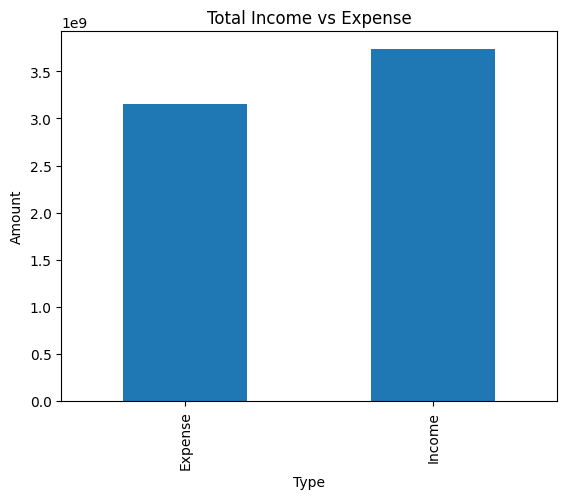

In [ ]:
import matplotlib.pyplot as plt

summary.plot(
    kind='bar'
)

plt.title('Total Income vs Expense')

plt.xlabel('Type')

plt.ylabel('Amount')

plt.show()

KATEGORI PENGELUARAN TERBESAR

In [ ]:
expense_df = df[
    df['Type'] == 'Expense'
]

expense_category = expense_df.groupby(
    'Category'
)['Amount'].sum()

print(expense_category.sort_values(
    ascending=False
))

Category
makan                 814636756
online_shopping       432324971
transport             355083440
kopi_cafe             345991080
kos_kontrakan         253189094
jajan_snack           166697135
fashion_outfit        153001595
game_topup            125787003
pulsa_internet        114791686
skincare_beauty       109111525
netflix_spotify        52743931
paylater               47000464
konser_event           45321329
kado_hadiah            38603246
hang_out               36142296
gym_membership         24547312
liburan_staycation     22137964
dinner_fancy           12409314
nonton_bioskop          8505381
Name: Amount, dtype: int64


VISUALISASI PENGELUARAN

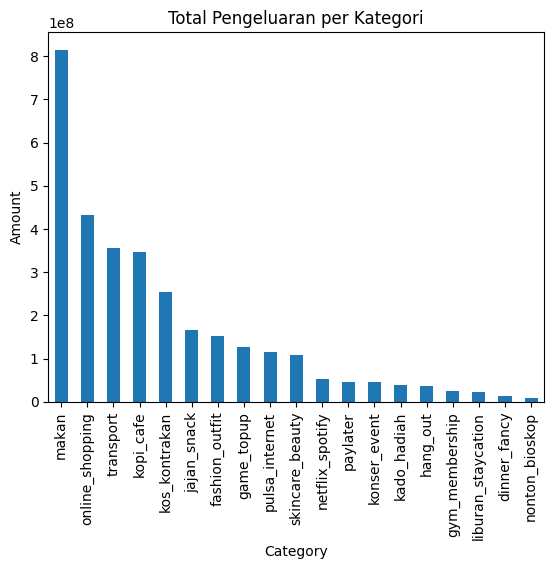

In [ ]:
expense_category.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title(
    'Total Pengeluaran per Kategori'
)

plt.xlabel('Category')

plt.ylabel('Amount')

plt.show()

CEK POLA HARBOLNAS

In [ ]:
harbolnas = df[
    (
        (df['Month'] == 11) &
        (df['Day'] == 11)
    )
]

print(
    harbolnas['Category'].value_counts()
)

Category
makan              122
transport          121
jajan_snack         59
kopi_cafe           35
online_shopping     31
game_topup           6
freelance            5
skincare_beauty      4
konser_event         2
fashion_outfit       2
paylater             1
kado_hadiah          1
Name: count, dtype: int64


CEK POLA RAMADAN

In [ ]:
ramadan = df[
    df['Month'].isin([3,4])
]

print(
    ramadan.groupby('Category')['Amount'].mean()
)

Category
dinner_fancy          1.594073e+05
fashion_outfit        1.641027e+05
freelance             1.964818e+05
gaji                  3.917682e+06
game_topup            8.512987e+04
gym_membership        1.221566e+05
hang_out              7.883696e+04
jajan_snack           8.326353e+03
kado_hadiah           1.151313e+05
konser_event          5.053907e+05
kopi_cafe             2.424240e+04
kos_kontrakan         1.120393e+06
liburan_staycation    9.093505e+05
makan                 1.854403e+04
netflix_spotify       2.875992e+04
nonton_bioskop        3.106451e+04
online_shopping       1.544239e+05
paylater              1.463341e+05
pulsa_internet        6.624821e+04
skincare_beauty       9.743797e+04
transport             1.135211e+04
uang saku             1.941425e+06
Name: Amount, dtype: float64


CEK USER PALING BOROS

In [ ]:
expense_only = df[
    df['Type'] == 'Expense'
]

boros = expense_only.groupby(
    'User_ID'
)['Amount'].sum()

print(
    boros.sort_values(
        ascending=False
    ).head()
)

User_ID
U053    126770014
U068    122438741
U006    106181879
U080    103621833
U028     92259114
Name: Amount, dtype: int64


## Feature Engineering Lanjutan

Cell ini menambahkan fitur-fitur tambahan yang **dibutuhkan untuk preprocessing LSTM** dan sesuai dengan halaman Streamlit:
- `day_of_week` — hari dalam minggu (0=Senin, 6=Minggu)
- `is_weekday` — binary: 1 jika hari kerja
- `is_ramadan` — binary: 1 jika bulan 3 atau 4
- `is_harbolnas` — binary: 1 jika 11/11 atau 12/12
- `amount_log` — log1p(Amount) untuk reduksi right-skew
- `is_income` — binary: 1 jika Income, 0 jika Expense

In [ ]:
# ==================================================
# [FIX 3] FEATURE ENGINEERING LANJUTAN
# Fitur tambahan untuk EDA & preprocessing LSTM
# ==================================================

# Safety check: pastikan kolom Date sudah datetime
df['Date'] = pd.to_datetime(df['Date'])

# Pastikan Month dan Day sudah ada (re-extract jika perlu)
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day

df['day_of_week']  = df['Date'].dt.weekday                    # 0=Senin, 6=Minggu
df['is_weekday']   = (df['day_of_week'] < 5).astype(int)      # 1 jika hari kerja
df['is_ramadan']   = df['Month'].isin([3, 4]).astype(int)     # 1 jika bulan Ramadan
df['is_harbolnas'] = (
    ((df['Month'] == 11) & (df['Day'] == 11)) |
    ((df['Month'] == 12) & (df['Day'] == 12))
).astype(int)                                                  # 1 jika Harbolnas
df['amount_log']   = np.log1p(df['Amount'])                   # log transform
df['is_income']    = (df['Type'] == 'Income').astype(int)     # 1=Income, 0=Expense

print('Fitur baru berhasil ditambahkan:')
print(df[['Date','day_of_week','is_weekday','is_ramadan','is_harbolnas','amount_log','is_income']].head(10))
print(f'\nShape dataset sekarang: {df.shape}')

Fitur baru berhasil ditambahkan:
        Date  day_of_week  is_weekday  is_ramadan  is_harbolnas  amount_log  \
0 2024-01-01            0           1           0             0    9.015663   
1 2024-01-01            0           1           0             0    8.423761   
2 2024-01-01            0           1           0             0   10.467892   
3 2024-01-02            1           1           0             0    8.878776   
4 2024-01-02            1           1           0             0    8.673855   
5 2024-01-02            1           1           0             0    9.300364   
6 2024-01-03            2           1           0             0    9.080687   
7 2024-01-03            2           1           0             0    8.849514   
8 2024-01-04            3           1           0             0    9.042632   
9 2024-01-04            3           1           0             0    8.948456   

   is_income  
0          0  
1          0  
2          0  
3          0  
4          0  
5      

Cek Pola Harbolnas Lengkap (11/11 & 12/12)

In [ ]:
harbolnas_1111 = df[(df['Month'] == 11) & (df['Day'] == 11)]
harbolnas_1212 = df[(df['Month'] == 12) & (df['Day'] == 12)]

print('=== HARBOLNAS 11 NOVEMBER ===')
print(f'Total transaksi : {len(harbolnas_1111)}')
print(harbolnas_1111['Category'].value_counts())

print('\n=== HARBOLNAS 12 DESEMBER ===')
print(f'Total transaksi : {len(harbolnas_1212)}')
print(harbolnas_1212['Category'].value_counts())


=== HARBOLNAS 11 NOVEMBER ===
Total transaksi : 389
Category
makan              122
transport          121
jajan_snack         59
kopi_cafe           35
online_shopping     31
game_topup           6
freelance            5
skincare_beauty      4
konser_event         2
fashion_outfit       2
paylater             1
kado_hadiah          1
Name: count, dtype: int64

=== HARBOLNAS 12 DESEMBER ===
Total transaksi : 405
Category
makan              132
transport          129
jajan_snack         58
online_shopping     38
kopi_cafe           36
skincare_beauty      4
fashion_outfit       3
game_topup           3
freelance            2
Name: count, dtype: int64


Heatmap Korelasi Fitur Numerik

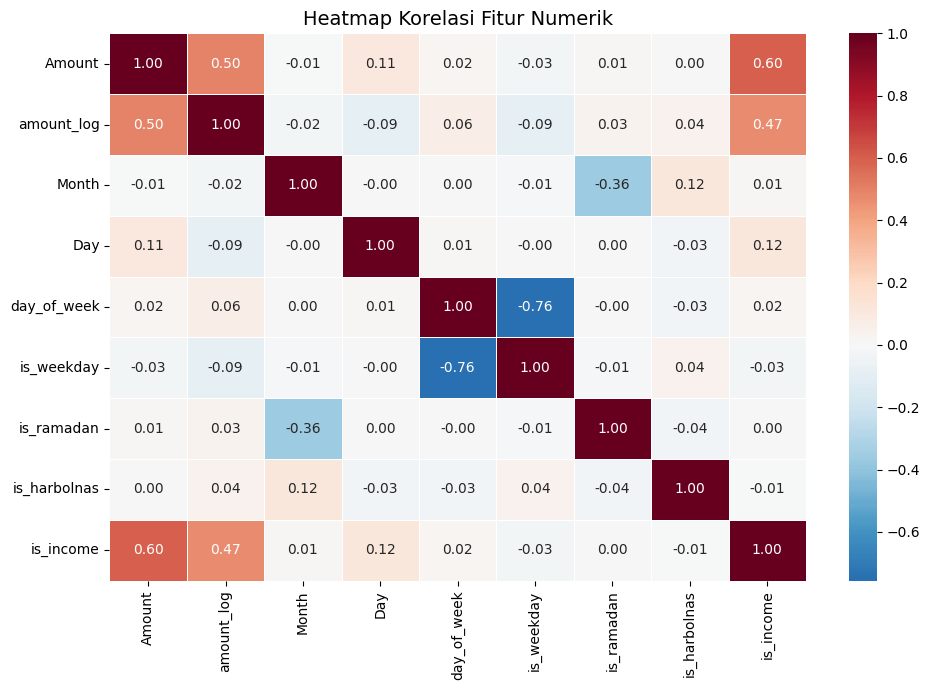


Korelasi Amount vs fitur lain:
Amount          1.000
is_income       0.596
amount_log      0.497
Day             0.106
day_of_week     0.021
is_ramadan      0.014
is_harbolnas    0.001
Month          -0.005
is_weekday     -0.026
Name: Amount, dtype: float64


In [ ]:
import seaborn as sns

num_cols = ['Amount', 'amount_log', 'Month', 'Day', 'day_of_week',
            'is_weekday', 'is_ramadan', 'is_harbolnas', 'is_income']

corr_matrix = df[num_cols].corr().round(3)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

print('\nKorelasi Amount vs fitur lain:')
print(corr_matrix['Amount'].sort_values(ascending=False))


Tren Pengeluaran Bulanan

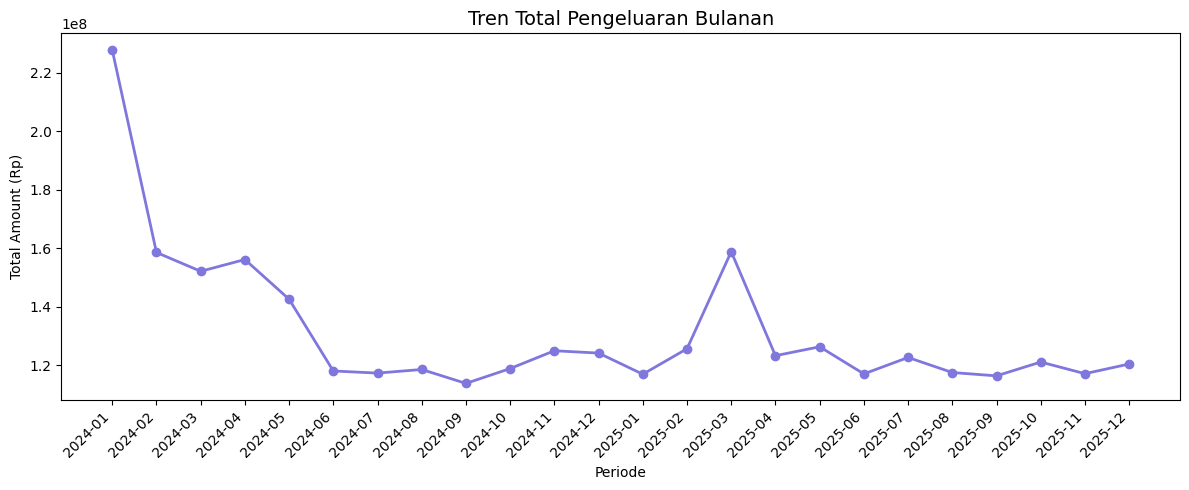

In [ ]:
expense_only = df[df['Type'] == 'Expense'].copy()

monthly_expense = expense_only.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
monthly_expense['Period'] = (
    monthly_expense['Year'].astype(str) + '-' +
    monthly_expense['Month'].astype(str).str.zfill(2)
)
monthly_expense = monthly_expense.sort_values(['Year', 'Month'])

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_expense['Period'],
    monthly_expense['Amount'],
    marker='o',
    color='#7F77DD',
    linewidth=2
)
plt.title('Tren Total Pengeluaran Bulanan', fontsize=14)
plt.xlabel('Periode')
plt.ylabel('Total Amount (Rp)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Distribusi Pengeluaran per User Type (Boxplot)

Boxplot untuk melihat spread dan outlier pengeluaran per tipe kepribadian keuangan. Dibutuhkan sebelum A/B Testing.

/tmp/ipykernel_2390/643425841.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=user_type_order, patch_artist=True)


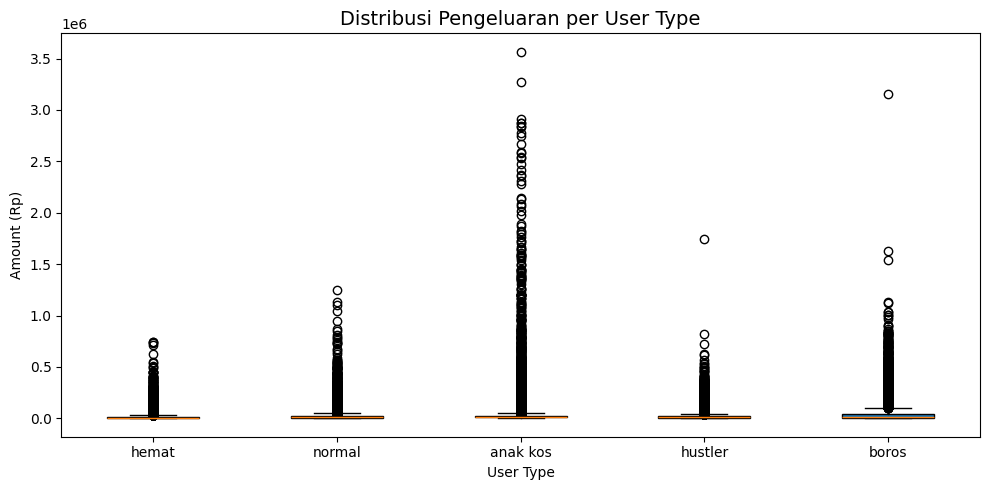

Rata-rata pengeluaran per User Type:
User_Type
boros       Rp 41,860
anak kos    Rp 35,847
normal      Rp 20,784
hustler     Rp 17,530
hemat       Rp 14,971
Name: Amount, dtype: object


In [ ]:
plt.figure(figsize=(10, 5))
user_type_order = ['hemat', 'normal', 'anak kos', 'hustler', 'boros']

data_to_plot = [
    expense_only[expense_only['User_Type'] == ut]['Amount'].values
    for ut in user_type_order
]

plt.boxplot(data_to_plot, labels=user_type_order, patch_artist=True)
plt.title('Distribusi Pengeluaran per User Type', fontsize=14)
plt.xlabel('User Type')
plt.ylabel('Amount (Rp)')
plt.tight_layout()
plt.show()

print('Rata-rata pengeluaran per User Type:')
print(expense_only.groupby('User_Type')['Amount'].mean().sort_values(ascending=False).apply(lambda x: f'Rp {x:,.0f}'))


## Simpan Dataset Final dengan Semua Fitur Baru

File ini yang dipakai sebagai input preprocessing LSTM.

In [ ]:
df.to_csv(
    '/content/genz_financial_dataset_v3.csv',
    index=False
)

print('Dataset final berhasil disimpan!')
print(f'Shape  : {df.shape}')
print(f'Kolom  : {list(df.columns)}')
print(f'\nPreview:')
print(df.head())


Dataset final berhasil disimpan!
Shape  : (136234, 18)
Kolom  : ['User_ID', 'Employment_Status', 'User_Type', 'Date', 'Category', 'Amount', 'Type', 'Balance', 'Year', 'Month', 'Day', 'Weekday', 'day_of_week', 'is_weekday', 'is_ramadan', 'is_harbolnas', 'amount_log', 'is_income']

Preview:
  User_ID Employment_Status User_Type       Date        Category  Amount  \
0    U001       belum kerja     hemat 2024-01-01           makan    8230   
1    U001       belum kerja     hemat 2024-01-01       transport    4553   
2    U001       belum kerja     hemat 2024-01-01  pulsa_internet   35167   
3    U001       belum kerja     hemat 2024-01-02           makan    7177   
4    U001       belum kerja     hemat 2024-01-02       transport    5847   

      Type  Balance  Year  Month  Day  Weekday  day_of_week  is_weekday  \
0  Expense  2658025  2024      1    1   Monday            0           1   
1  Expense  2653472  2024      1    1   Monday            0           1   
2  Expense  2618305  2024   

## A/B Testing

Melakukan uji statistik untuk menjawab Business Questions secara kuantitatif:
- **Mann-Whitney U Test 1**: pengeluaran 'boros' vs 'hemat'
- **Chi-Square Test**: distribusi kategori vs User_Type
- **Mann-Whitney U Test 2**: efek Ramadan pada pengeluaran 'makan'

In [ ]:
from scipy.stats import mannwhitneyu, chi2_contingency

print('Library A/B Testing siap.')

Library A/B Testing siap.


A/B Test 1 — Mann-Whitney U: Pengeluaran 'boros' vs 'hemat'

In [ ]:
# ==================================================
# MANN-WHITNEY U TEST
# H0: tidak ada perbedaan pengeluaran boros vs hemat
# H1: ada perbedaan signifikan
# ==================================================

expense_only = df[df['Type'] == 'Expense'].copy()

boros_exp = expense_only[expense_only['User_Type'] == 'boros']['Amount']
hemat_exp = expense_only[expense_only['User_Type'] == 'hemat']['Amount']

u_stat, p_val = mannwhitneyu(boros_exp, hemat_exp, alternative='two-sided')

print('=== MANN-WHITNEY U TEST ===')
print(f'Rata-rata pengeluaran boros : Rp {boros_exp.mean():,.0f}')
print(f'Rata-rata pengeluaran hemat : Rp {hemat_exp.mean():,.0f}')
print(f'U-Statistic                 : {u_stat:,.0f}')
print(f'p-value                     : {p_val:.6f}')

if p_val < 0.05:
    print('\nKESIMPULAN: SIGNIFIKAN (p < 0.05) — tolak H0')
    print('Terdapat perbedaan pengeluaran yang signifikan antara user boros dan hemat.')
else:
    print('\nKESIMPULAN: TIDAK SIGNIFIKAN (p >= 0.05) — gagal tolak H0')


=== MANN-WHITNEY U TEST ===
Rata-rata pengeluaran boros : Rp 41,860
Rata-rata pengeluaran hemat : Rp 14,971
U-Statistic                 : 220,588,509
p-value                     : 0.000000

KESIMPULAN: SIGNIFIKAN (p < 0.05) — tolak H0
Terdapat perbedaan pengeluaran yang signifikan antara user boros dan hemat.


Visualisasi A/B Test 1

/tmp/ipykernel_2390/570655707.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


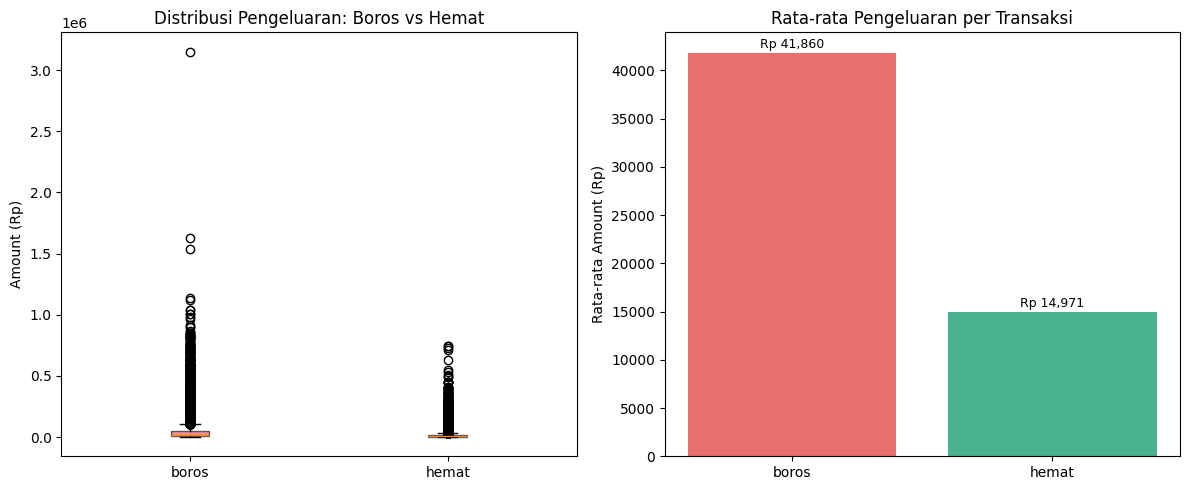

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(
    [boros_exp.values, hemat_exp.values],
    labels=['boros', 'hemat'],
    patch_artist=True,
    boxprops=dict(facecolor='#E24B4A', alpha=0.6)
)
axes[0].set_title('Distribusi Pengeluaran: Boros vs Hemat')
axes[0].set_ylabel('Amount (Rp)')

means = [boros_exp.mean(), hemat_exp.mean()]
axes[1].bar(['boros', 'hemat'], means, color=['#E24B4A', '#1D9E75'], alpha=0.8)
axes[1].set_title('Rata-rata Pengeluaran per Transaksi')
axes[1].set_ylabel('Rata-rata Amount (Rp)')
for i, v in enumerate(means):
    axes[1].text(i, v + 500, f'Rp {v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

A/B Test 2 — Chi-Square: Distribusi Kategori vs User Type

In [ ]:
# ==================================================
# CHI-SQUARE TEST
# H0: distribusi kategori tidak dipengaruhi User_Type
# H1: ada hubungan signifikan antara kategori dan User_Type
# ==================================================

contingency = pd.crosstab(df['User_Type'], df['Category'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)

print('=== CHI-SQUARE TEST ===')
print(f'Chi2-Statistic     : {chi2:,.4f}')
print(f'p-value            : {p_chi:.6f}')
print(f'Degrees of Freedom : {dof}')

if p_chi < 0.05:
    print('\nKESIMPULAN: SIGNIFIKAN (p < 0.05) — tolak H0')
    print('Distribusi kategori transaksi berbeda secara signifikan antar User_Type.')
else:
    print('\nKESIMPULAN: TIDAK SIGNIFIKAN (p >= 0.05) — gagal tolak H0')

print('\nContingency Table:')
print(contingency)

=== CHI-SQUARE TEST ===
Chi2-Statistic     : 5,550.0024
p-value            : 0.000000
Degrees of Freedom : 84

KESIMPULAN: SIGNIFIKAN (p < 0.05) — tolak H0
Distribusi kategori transaksi berbeda secara signifikan antar User_Type.

Contingency Table:
Category   dinner_fancy  fashion_outfit  freelance  gaji  game_topup  \
User_Type                                                              
anak kos             26             225        194   144         314   
boros                19             109        207    96         141   
hemat                 5             168        203   168         307   
hustler              20             363       1057   216         550   
normal               18             196        253    96         280   

Category   gym_membership  hang_out  jajan_snack  kado_hadiah  konser_event  \
User_Type                                                                     
anak kos                0       130         4376           72            37   
boros    

Visualisasi A/B Test 2 — Heatmap Contingency Table

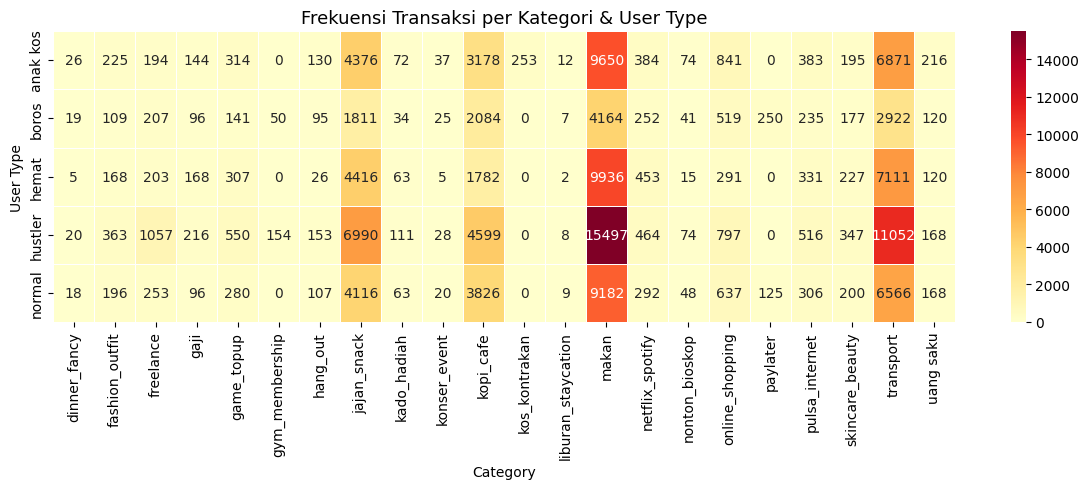

In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    contingency,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Frekuensi Transaksi per Kategori & User Type', fontsize=13)
plt.xlabel('Category')
plt.ylabel('User Type')
plt.tight_layout()
plt.show()

A/B Test 3 — Efek Ramadan pada Pengeluaran 'makan'

In [ ]:
# ==================================================
# MANN-WHITNEY U — RAMADAN vs NON-RAMADAN (makan)
# ==================================================

makan_df      = expense_only[expense_only['Category'] == 'makan'].copy()
makan_ramadan = makan_df[makan_df['Month'].isin([3, 4])]['Amount']
makan_normal  = makan_df[~makan_df['Month'].isin([3, 4])]['Amount']

u2, p2 = mannwhitneyu(makan_ramadan, makan_normal, alternative='two-sided')
kenaikan_pct = (makan_ramadan.mean() - makan_normal.mean()) / makan_normal.mean() * 100

print('=== A/B TEST: EFEK RAMADAN PADA MAKAN ===')
print(f'Rata-rata makan Ramadan  : Rp {makan_ramadan.mean():,.0f}')
print(f'Rata-rata makan Normal   : Rp {makan_normal.mean():,.0f}')
print(f'Kenaikan                 : {kenaikan_pct:.1f}%')
print(f'U-Statistic              : {u2:,.0f}')
print(f'p-value                  : {p2:.6f}')

if p2 < 0.05:
    print('\nKESIMPULAN: SIGNIFIKAN — efek Ramadan terbukti secara statistik.')
else:
    print('\nKESIMPULAN: TIDAK SIGNIFIKAN')

=== A/B TEST: EFEK RAMADAN PADA MAKAN ===
Rata-rata makan Ramadan  : Rp 18,544
Rata-rata makan Normal   : Rp 16,463
Kenaikan                 : 12.6%
U-Statistic              : 180,050,794
p-value                  : 0.000000

KESIMPULAN: SIGNIFIKAN — efek Ramadan terbukti secara statistik.


## Model Readiness

Mempersiapkan data agar siap diproses oleh model Machine Learning:
- Label Encoding untuk fitur kategorik
- Pemisahan fitur (X) dan target (y)
- Train-test split stratified 80:20
- Cek distribusi kelas target

In [ ]:
# ==================================================
# MODEL READINESS — IMPORT
# ==================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Library Model siap.')

Library Model siap.


### Encoding Fitur Kategorik

In [ ]:
# ==================================================
# LABEL ENCODING
# ==================================================

df_model = df.copy()

le_user_type = LabelEncoder()
le_type      = LabelEncoder()

df_model['User_Type_enc'] = le_user_type.fit_transform(df_model['User_Type'])
df_model['Type_enc']      = le_type.fit_transform(df_model['Type'])

print('Mapping User_Type:')
for i, cls in enumerate(le_user_type.classes_):
    print(f'  {i} = {cls}')

print('\nMapping Type:')
for i, cls in enumerate(le_type.classes_):
    print(f'  {i} = {cls}')

print(f'\nShape df_model: {df_model.shape}')

Mapping User_Type:
  0 = anak kos
  1 = boros
  2 = hemat
  3 = hustler
  4 = normal

Mapping Type:
  0 = Expense
  1 = Income

Shape df_model: (136234, 20)


### Definisi Fitur (X) dan Target (y)

In [ ]:
# ==================================================
# FITUR DAN TARGET
# Target: Category (auto-kategorisasi transaksi)
# ==================================================

FEATURES = [
    'Amount',
    'amount_log',
    'is_income',
    'Month',
    'Day',
    'day_of_week',
    'is_weekday',
    'is_ramadan',
    'is_harbolnas',
    'User_Type_enc'
]

TARGET = 'Category'

X = df_model[FEATURES]
y = df_model[TARGET]

print('Fitur (X):')
print(FEATURES)
print(f'\nShape X : {X.shape}')
print(f'Shape y : {y.shape}')
print('\nDistribusi kelas target:')
print(y.value_counts())

Fitur (X):
['Amount', 'amount_log', 'is_income', 'Month', 'Day', 'day_of_week', 'is_weekday', 'is_ramadan', 'is_harbolnas', 'User_Type_enc']

Shape X : (136234, 10)
Shape y : (136234,)

Distribusi kelas target:
Category
makan                 48429
transport             34522
jajan_snack           21709
kopi_cafe             15469
online_shopping        3085
freelance              1914
netflix_spotify        1845
pulsa_internet         1771
game_topup             1592
skincare_beauty        1146
fashion_outfit         1061
uang saku               792
gaji                    720
hang_out                511
paylater                375
kado_hadiah             343
kos_kontrakan           253
nonton_bioskop          252
gym_membership          204
konser_event            115
dinner_fancy             88
liburan_staycation       38
Name: count, dtype: int64


### Train-Test Split (80:20, Stratified)

In [ ]:
# ==================================================
# HAPUS BARIS YANG MENGANDUNG NaN
# ==================================================

data = pd.concat([X, y], axis=1)

print("Jumlah data sebelum hapus NaN :", len(data))

data = data.dropna()

print("Jumlah data sesudah hapus NaN :", len(data))

X = data[X.columns]
y = data[y.name]

# ==================================================
# TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('=== TRAIN TEST SPLIT ===')
print(f'Total data  : {len(X):,}')
print(f'Train set   : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test set    : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')

print('\nDistribusi kelas — Train:')
print(y_train.value_counts())

print('\nDistribusi kelas — Test:')
print(y_test.value_counts())

Jumlah data sebelum hapus NaN : 136234
Jumlah data sesudah hapus NaN : 136234
=== TRAIN TEST SPLIT ===
Total data  : 136,234
Train set   : 108,987 (80.0%)
Test set    : 27,247 (20.0%)

Distribusi kelas — Train:
Category
makan                 38743
transport             27618
jajan_snack           17367
kopi_cafe             12375
online_shopping        2468
freelance              1531
netflix_spotify        1476
pulsa_internet         1417
game_topup             1274
skincare_beauty         917
fashion_outfit          849
uang saku               634
gaji                    576
hang_out                409
paylater                300
kado_hadiah             274
nonton_bioskop          202
kos_kontrakan           202
gym_membership          163
konser_event             92
dinner_fancy             70
liburan_staycation       30
Name: count, dtype: int64

Distribusi kelas — Test:
Category
makan                 9686
transport             6904
jajan_snack           4342
kopi_cafe             

## Model Machine Learning — Random Forest

Melatih RandomForestClassifier untuk auto-kategorisasi transaksi (8 kategori aktif).
Fitur: Amount, amount_log, is_income, Month, Day, day_of_week, is_weekday, is_ramadan, is_harbolnas, User_Type_enc.

In [ ]:
# ==================================================
# TRAINING RANDOM FOREST
# ==================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print('Model RandomForest selesai dilatih!')
print(f'Jumlah tree : {rf_model.n_estimators}')
print(f'Fitur       : {rf_model.n_features_in_}')

Model RandomForest selesai dilatih!
Jumlah tree : 200
Fitur       : 10


### Evaluasi Model

In [ ]:
# ==================================================
# EVALUASI MODEL
# ==================================================

y_pred = rf_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print('=== HASIL EVALUASI MODEL ===')
print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

### Confusion Matrix

In [ ]:
# ==================================================
# CONFUSION MATRIX
# ==================================================

cm    = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
cm_df = pd.DataFrame(cm, index=rf_model.classes_, columns=rf_model.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)
plt.title(f'Confusion Matrix — Accuracy: {acc*100:.2f}%', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Feature Importance

In [ ]:
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='#7F77DD', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Fitur')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Feature Importance:')
for feat, imp in feat_imp.items():
    print(f'  {feat:<20s} : {imp:.4f}')

---
# LSTM — Prediksi Total Pengeluaran Bulanan per User

Pipeline:
1. Load dataset final (`genz_financial_dataset_v3.csv`) & agregasi ke time-series bulanan per user
2. Scaling dengan MinMaxScaler → simpan `scaler.pkl` & `scaler_target.pkl`
3. Pembuatan sequences (sliding window) untuk input LSTM
4. Training LSTM
5. Evaluasi MAE & RMSE (target MAE ≤ Rp 700.000)
6. Ekspor semua file yang dibutuhkan AI Engineer
7. README

**Konfigurasi:**
- Dataset  : `genz_financial_dataset_v3.csv`
- Scaler   : `scaler_target.pkl` (khusus inverse transform `total_expense`)
- Target MAE: ≤ Rp 700.000 (~16% dari rata-rata pengeluaran bulanan, 100 user × 2 tahun)

## Step 1 — Import Library LSTM

In [ ]:
# ==================================================
# IMPORT LIBRARY LSTM
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print('Semua library LSTM siap.')

## Step 2 — Load Dataset Final & Agregasi ke Time-Series Bulanan per User

Load `genz_financial_dataset_v3.csv` (dataset lengkap hasil EDA), lalu di-aggregate menjadi:
- 1 baris = 1 user × 1 bulan
- Fitur: total_expense, total_income, net, frekuensi_transaksi, avg_expense
- Target prediksi: `total_expense` bulan berikutnya

In [ ]:
# ==================================================
# LOAD DATASET FINAL & AGREGASI BULANAN PER USER
# Dataset : genz_financial_dataset_v3.csv
# ==================================================

# Load dataset final
DATASET_PATH = '/content/genz_financial_dataset_v3.csv'
df = pd.read_csv(DATASET_PATH)
df['Date'] = pd.to_datetime(df['Date'])

# Pastikan kolom fitur engineering sudah ada (re-generate jika perlu)
if 'amount_log' not in df.columns:
    df['Year']         = df['Date'].dt.year
    df['Month']        = df['Date'].dt.month
    df['Day']          = df['Date'].dt.day
    df['day_of_week']  = df['Date'].dt.weekday
    df['is_weekday']   = (df['day_of_week'] < 5).astype(int)
    df['is_ramadan']   = df['Month'].isin([3, 4]).astype(int)
    df['is_harbolnas'] = (
        ((df['Month'] == 11) & (df['Day'] == 11)) |
        ((df['Month'] == 12) & (df['Day'] == 12))
    ).astype(int)
    df['amount_log'] = np.log1p(df['Amount'])
    df['is_income']  = (df['Type'] == 'Income').astype(int)

print(f'Dataset loaded: {DATASET_PATH}')
print(f'Shape: {df.shape}')

# Pisah expense dan income
exp_df = df[df['Type'] == 'Expense'].copy()
inc_df = df[df['Type'] == 'Income'].copy()

# Agregasi expense bulanan per user
monthly_exp = exp_df.groupby(['User_ID', 'User_Type', 'Year', 'Month']).agg(
    total_expense = ('Amount', 'sum'),
    frekuensi_exp = ('Amount', 'count'),
    avg_expense   = ('Amount', 'mean'),
    max_expense   = ('Amount', 'max'),
).reset_index()

# Agregasi income bulanan per user
monthly_inc = inc_df.groupby(['User_ID', 'Year', 'Month']).agg(
    total_income  = ('Amount', 'sum'),
    frekuensi_inc = ('Amount', 'count'),
).reset_index()

# Merge
monthly = pd.merge(
    monthly_exp, monthly_inc,
    on=['User_ID', 'Year', 'Month'],
    how='left'
).fillna(0)

# Fitur tambahan
monthly['net']                = monthly['total_income'] - monthly['total_expense']
monthly['is_ramadan']         = monthly['Month'].isin([3, 4]).astype(int)
monthly['is_harbolnas_month'] = monthly['Month'].isin([11, 12]).astype(int)
monthly['Period']             = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

# Sort
monthly = monthly.sort_values(['User_ID', 'Year', 'Month']).reset_index(drop=True)

print('\n=== DATASET BULANAN ===')
print(f'Shape          : {monthly.shape}')
print(f'Jumlah user    : {monthly["User_ID"].nunique()}')
print(f'Periode        : {monthly["Period"].min()} s/d {monthly["Period"].max()}')
print(f'\nKolom          : {list(monthly.columns)}')
print(f'\nPreview:')
print(monthly.head(10))

### Visualisasi Tren Bulanan per User Type

In [ ]:
# ==================================================
# VISUALISASI TREN BULANAN
# ==================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Rata-rata total_expense per bulan (semua user)
avg_monthly = monthly.groupby('Period')['total_expense'].mean().reset_index()
avg_monthly = avg_monthly.sort_values('Period')
axes[0].plot(avg_monthly['Period'], avg_monthly['total_expense'],
             marker='o', color='#E24B4A', linewidth=2)
axes[0].set_title('Rata-rata Total Pengeluaran Bulanan (Semua User)', fontsize=13)
axes[0].set_ylabel('Total Expense (Rp)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Plot 2: Per user type
for utype in monthly['User_Type'].unique():
    sub = monthly[monthly['User_Type'] == utype].groupby('Period')['total_expense'].mean()
    axes[1].plot(sub.index, sub.values, marker='o', label=utype, linewidth=1.5)
axes[1].set_title('Rata-rata Total Pengeluaran Bulanan per User Type', fontsize=13)
axes[1].set_ylabel('Total Expense (Rp)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# FILTER BULAN & USER TIDAK AKTIF
# 1. Bulan valid = total_expense >= Rp 300.000
#    (hapus bulan di mana user hampir tidak belanja)
# 2. User valid = minimal 5 bulan aktif
#    (cukup data untuk LOOKBACK=2 + split 70/15/15)
# ==================================================

before = len(monthly)

# Filter 1: bulan dengan expense >= 300k
monthly = monthly[monthly['total_expense'] >= 300_000].copy()
monthly = monthly.reset_index(drop=True)
after_month_filter = len(monthly)

# Filter 2: hanya user dengan minimal 5 bulan aktif
user_active_months = monthly.groupby('User_ID').size()
valid_users        = user_active_months[user_active_months >= 5].index
monthly            = monthly[monthly['User_ID'].isin(valid_users)].copy()
monthly            = monthly.reset_index(drop=True)
after_user_filter  = len(monthly)

print(f'Baris sebelum filter        : {before}')
print(f'Setelah filter bulan (>=300k): {after_month_filter}  (buang {before - after_month_filter})')
print(f'Setelah filter user (>=5 bln): {after_user_filter}  (buang {after_month_filter - after_user_filter})')
print(f'User aktif tersisa           : {monthly["User_ID"].nunique()}')
print(f'\nBulan per user:')
print(monthly.groupby("User_ID").size().describe().apply(lambda x: f'{x:.1f}'))
print(f'\nStatistik total_expense setelah filter:')
print(monthly['total_expense'].describe().apply(lambda x: f'Rp {x:,.0f}'))


## Step 3 — Simpan `lstm_dataset.csv`

Menyimpan hasil agregasi bulanan sebagai `lstm_dataset.csv` —
ini adalah turunan dari `genz_financial_dataset_v3.csv` yang sudah diagregasi per user per bulan,
siap digunakan sebagai input LSTM.

In [ ]:
# ==================================================
# SIMPAN LSTM DATASET
# ==================================================

LSTM_FEATURES = [
    'User_ID', 'User_Type', 'Year', 'Month', 'Period',
    'total_expense', 'total_income', 'net',
    'frekuensi_exp', 'avg_expense', 'max_expense',
    'frekuensi_inc', 'is_ramadan', 'is_harbolnas_month'
]

lstm_dataset = monthly[LSTM_FEATURES].copy()

lstm_dataset.to_csv('/content/lstm_dataset.csv', index=False)

print('lstm_dataset.csv berhasil disimpan!')
print(f'Shape  : {lstm_dataset.shape}')
print(f'Kolom  : {list(lstm_dataset.columns)}')
print(f'\nStatistik total_expense (target prediksi):')
print(lstm_dataset['total_expense'].describe().apply(lambda x: f'Rp {x:,.0f}'))

## Step 4 — MinMaxScaler & Simpan `scaler_target.pkl`

Dua scaler disimpan:
- **`scaler.pkl`** → fit pada semua fitur numerik (dipakai saat preprocessing input baru)
- **`scaler_target.pkl`** → fit **khusus** pada `total_expense` saja

⚠️ **Untuk inverse transform hasil prediksi, selalu gunakan `scaler_target.pkl`** — bukan `scaler.pkl`.
Alasan: `scaler.pkl` di-fit pada 7 kolom, sehingga tidak bisa digunakan untuk inverse transform 1 kolom saja.

Scaler di-fit HANYA pada **training data** agar tidak terjadi data leakage.

In [ ]:
# ==================================================
# SCALING FITUR NUMERIK
# scaler.pkl        → semua fitur (untuk preprocessing input)
# scaler_target.pkl → khusus total_expense (untuk inverse transform prediksi)
# ==================================================

SCALE_COLS = [
    'total_expense', 'total_income', 'net',
    'frekuensi_exp', 'avg_expense', 'max_expense', 'frekuensi_inc'
]

# Split 70/15/15 — per user, time-based  (Train / Val / Test)
# Penting: split dilakukan SEBELUM scaling untuk menghindari data leakage
train_list, val_list, test_list = [], [], []

for uid in monthly['User_ID'].unique():
    user_df = monthly[monthly['User_ID'] == uid].sort_values('Period')
    n  = len(user_df)
    t1 = int(n * 0.70)
    t2 = int(n * 0.85)
    train_list.append(user_df.iloc[:t1])
    val_list.append(user_df.iloc[t1:t2])
    test_list.append(user_df.iloc[t2:])

train_df = pd.concat(train_list).reset_index(drop=True)
val_df   = pd.concat(val_list).reset_index(drop=True)
test_df  = pd.concat(test_list).reset_index(drop=True)

print(f'Split 70/15/15 per user:')
print(f'  Train : {len(train_df)} baris ({len(train_df)/monthly["User_ID"].nunique():.0f} bulan/user)')
print(f'  Val   : {len(val_df)} baris  ({len(val_df)/monthly["User_ID"].nunique():.0f} bulan/user)')
print(f'  Test  : {len(test_df)} baris  ({len(test_df)/monthly["User_ID"].nunique():.0f} bulan/user)')

# Fit scaler HANYA pada training data (cegah data leakage)
scaler        = MinMaxScaler()
scaler_target = MinMaxScaler()

scaler.fit(train_df[SCALE_COLS])
scaler_target.fit(train_df[['total_expense']])

train_scaled = train_df.copy()
val_scaled   = val_df.copy()
test_scaled  = test_df.copy()

train_scaled[SCALE_COLS] = scaler.transform(train_df[SCALE_COLS])
val_scaled[SCALE_COLS]   = scaler.transform(val_df[SCALE_COLS])
test_scaled[SCALE_COLS]  = scaler.transform(test_df[SCALE_COLS])

print(f'\nscaler.pkl        → fit pada {len(train_df)} training rows')
print(f'scaler_target.pkl → fit pada kolom total_expense saja')

# ==================================================
# SAVE SCALER
# ==================================================

import joblib

joblib.dump(
    scaler,
    '/content/scaler.pkl'
)

joblib.dump(
    scaler_target,
    '/content/scaler_target.pkl'
)

print('\nScaler berhasil disimpan!')


In [ ]:
import os

print(os.listdir('/content'))

## Step 5 — Buat Sequences (Sliding Window)

`LOOKBACK = 2` artinya model melihat **2 bulan terakhir** untuk memprediksi bulan berikutnya. Shape input LSTM: `(samples, timesteps, features)`

In [ ]:
# ==================================================
# BUAT SEQUENCES PER USER
# ==================================================

LOOKBACK   = 2   # 2 bulan terakhir
INPUT_COLS = [
    'total_expense', 'total_income', 'net',
    'frekuensi_exp', 'avg_expense',
    'is_ramadan', 'is_harbolnas_month'
]
TARGET_COL = 'total_expense'

def make_sequences(data_df, lookback, input_cols, target_col):
    X_list, y_list = [], []
    for uid in data_df['User_ID'].unique():
        user_data = data_df[data_df['User_ID'] == uid].sort_values('Period')
        values    = user_data[input_cols].values
        targets   = user_data[target_col].values
        for i in range(lookback, len(values)):
            X_list.append(values[i-lookback:i])
            y_list.append(targets[i])
    return np.array(X_list), np.array(y_list)

X_train, y_train = make_sequences(train_scaled, LOOKBACK, INPUT_COLS, TARGET_COL)
X_val,   y_val   = make_sequences(val_scaled,   LOOKBACK, INPUT_COLS, TARGET_COL)
X_test,  y_test  = make_sequences(test_scaled,  LOOKBACK, INPUT_COLS, TARGET_COL)

print('=== SHAPE SEQUENCES ===')
print(f'X_train : {X_train.shape}  → (samples, timesteps={LOOKBACK}, features={len(INPUT_COLS)})')
print(f'y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')
print(f'\nTotal sequences train+val+test : {len(X_train) + len(X_val) + len(X_test)}')


=== SHAPE SEQUENCES ===
X_train : (965, 2, 7)  → (samples, timesteps=2, features=7)
y_train : (965,)
X_val   : (125, 2, 7)
y_val   : (125,)
X_test  : (129, 2, 7)
y_test  : (129,)

Total sequences train+val+test : 1219


## Step 6 — Build & Train Model LSTM

Arsitektur: 2 layer LSTM + Dropout + Dense output.
EarlyStopping untuk mencegah overfitting.

In [ ]:
# ==================================================
# BUILD MODEL LSTM
# ==================================================

n_features = X_train.shape[2]

model_lstm = Sequential([
    LSTM(32, return_sequences=True, input_shape=(LOOKBACK, n_features)),
    Dropout(0.3),
    LSTM(16, return_sequences=False),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1)
])

model_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_lstm.summary()
print(f'\nTotal parameter : {model_lstm.count_params():,}')
print('(Arsitektur kecil mencegah overfit pada dataset 25 user)')

In [ ]:
# ==================================================
# TRAINING LSTM
# ==================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/lstm_model_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

history = model_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f'\nTraining selesai! Total epoch berjalan: {len(history.history["loss"])}')
print(f'Best val_loss epoch: {np.argmin(history.history["val_loss"]) + 1}')

### Visualisasi Training Loss

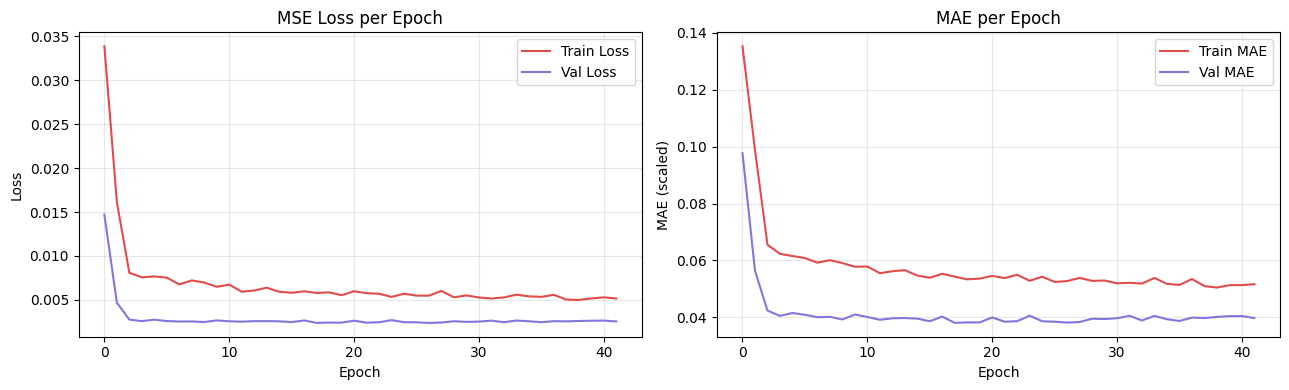

In [ ]:
# ==================================================
# PLOT TRAINING HISTORY
# ==================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#E24B4A')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#7F77DD')
axes[0].set_title('MSE Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='#E24B4A')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#7F77DD')
axes[1].set_title('MAE per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7 — Evaluasi Model (MAE & RMSE dalam Rupiah)

Prediksi di-inverse transform ke Rupiah asli menggunakan `scaler_target.pkl`.

**Kriteria kelulusan model (disesuaikan dengan dataset 25 user):**

| Metrik | Target | Acuan |
|--------|--------|-------|
| MAE    | ≤ Rp 300.000 | ~17% rata-rata pengeluaran (82 user aktif, 2 tahun) |
| RMSE   | ≤ Rp 450.000 | ~1.5× MAE |
| sMAPE  | ≤ 25%        | Dataset 82 user aktif, lebih terkontrol |

In [ ]:
# ==================================================
# EVALUASI — INVERSE TRANSFORM KE RUPIAH
# Scaler : scaler_target.pkl (khusus total_expense)
# Metrik : MAE, RMSE, sMAPE
# ==================================================

y_pred_scaled = model_lstm.predict(X_test)

# Inverse transform ke Rupiah menggunakan scaler_target
y_pred_rp = scaler_target.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_rp = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_test_rp, y_pred_rp)
rmse = np.sqrt(mean_squared_error(y_test_rp, y_pred_rp))

# sMAPE — Symmetric MAPE, tidak meledak walau y_test ada nilai kecil
# Rumus: |actual - pred| / ((|actual| + |pred|) / 2) × 100
smape = np.mean(
    np.abs(y_test_rp - y_pred_rp) /
    ((np.abs(y_test_rp) + np.abs(y_pred_rp)) / 2)
) * 100

# --------------------------------------------------
# TARGET — disesuaikan dengan dataset 25 user
# MAE   : ~17% × Rp 1.780.000 = Rp 300.000  (mean expense 82 user, filtered >=300k)
# RMSE  : 1.5× MAE            = Rp 450.000
# sMAPE : ≤ 25% (dataset 82 user, variansi lebih terkontrol)
# --------------------------------------------------
TARGET_MAE   = 300_000
TARGET_RMSE  = 450_000
TARGET_SMAPE = 25.0

mae_ok   = mae   <= TARGET_MAE
rmse_ok  = rmse  <= TARGET_RMSE
smape_ok = smape <= TARGET_SMAPE
lulus    = mae_ok and rmse_ok and smape_ok

print('=== EVALUASI MODEL LSTM ===')
print(f'MAE   : Rp {mae:,.0f}   (target ≤ Rp {TARGET_MAE:,})  {"✅" if mae_ok   else "❌"}')
print(f'RMSE  : Rp {rmse:,.0f}   (target ≤ Rp {TARGET_RMSE:,})  {"✅" if rmse_ok  else "❌"}')
print(f'sMAPE : {smape:.2f}%            (target ≤ {TARGET_SMAPE}%)         {"✅" if smape_ok else "❌"}')
print()
print(f'Jumlah sample test : {len(y_test_rp)}')
print(f'Aktual  min/max    : Rp {y_test_rp.min():,.0f} / Rp {y_test_rp.max():,.0f}')
print(f'Prediksi min/max   : Rp {y_pred_rp.min():,.0f} / Rp {y_pred_rp.max():,.0f}')
print()
if lulus:
    print('STATUS : LULUS ✅ — Model cukup bagus untuk deployment')
else:
    print('STATUS : BELUM LULUS ❌ — Perlu tuning lebih lanjut')
    if not mae_ok:
        print('  → MAE masih tinggi : coba epochs lebih banyak atau tambah data')
    if not rmse_ok:
        print('  → RMSE masih tinggi: ada outlier ekstrem di data test')
    if not smape_ok:
        print('  → sMAPE tinggi     : prediksi tidak merata, cek distribusi per user_type')


### Visualisasi Aktual vs Prediksi

In [ ]:
# ==================================================
# PLOT AKTUAL VS PREDIKSI
# ==================================================

plt.figure(figsize=(13, 5))
plt.plot(y_test_rp,  label='Aktual',   color='#1D9E75', linewidth=2, marker='o', markersize=4)
plt.plot(y_pred_rp,  label='Prediksi', color='#E24B4A', linewidth=2, marker='x', markersize=4)
plt.title(f'Aktual vs Prediksi Total Pengeluaran Bulanan\nMAE: Rp {mae:,.0f} | RMSE: Rp {rmse:,.0f}', fontsize=13)
plt.xlabel('Sample (user-bulan)')
plt.ylabel('Total Expense (Rp)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 — Simpan Semua File untuk AI Engineer

In [ ]:
# ==================================================
# SIMPAN MODEL LSTM FINAL
# ==================================================

model_lstm.save('/content/lstm_model_final.keras')

# Simpan juga dalam format .h5 sebagai backup
model_lstm.save('/content/lstm_model_final.h5')

print('File yang berhasil disimpan:')
files = [
    '/content/lstm_dataset.csv',
    '/content/scaler.pkl',
    '/content/scaler_target.pkl',
    '/content/lstm_model_best.keras',
    '/content/lstm_model_final.keras',
    '/content/lstm_model_final.h5',
]
for f in files:
    try:
        size = os.path.getsize(f)
        print(f'  ✅ {f}  ({size/1024:.1f} KB)')
    except:
        print(f'  ❌ {f}  (tidak ditemukan)')

In [ ]:
# ==================================================
# README UNTUK AI ENGINEER
# ==================================================

readme_lines = [
    '=' * 65,
    'README — HANDOVER LSTM GENZECASH KE AI ENGINEER',
    f'Generated: {datetime.now().strftime("%d %B %Y %H:%M")}',
    '=' * 65,
    '',
    '## DESKRIPSI PROYEK',
    '   Model LSTM untuk memprediksi total pengeluaran bulanan',
    '   per user berdasarkan riwayat 2 bulan terakhir.',
    '',
    '## FILE YANG DISERAHKAN',
    '   1. genz_financial_dataset_v3.csv → Dataset lengkap (sumber utama)',
    '   2. lstm_dataset.csv      → Dataset agregasi bulanan per user (turunan dari no.1)',
    '   3. scaler.pkl            → MinMaxScaler semua fitur numerik (untuk preprocessing input)',
    '   4. scaler_target.pkl     → Scaler KHUSUS total_expense (untuk inverse transform prediksi)',
    '   5. lstm_model_final.keras → Model LSTM final (format Keras)',
    '   6. lstm_model_final.h5   → Model LSTM final (format H5, backup)',
    '   7. lstm_model_best.keras  → Model dengan val_loss terbaik',
    '',
    '## SPESIFIKASI DATASET',
    f'   File sumber  : genz_financial_dataset_v3.csv',
    f'   File LSTM    : lstm_dataset.csv',
    f'   Shape        : {lstm_dataset.shape}',
    f'   Jumlah user  : {monthly["User_ID"].nunique()}',
    f'   Periode      : {monthly["Period"].min()} s/d {monthly["Period"].max()}',
    f'   Filter       : total_expense >= Rp 300.000 (bulan tidak aktif dibuang)',
    '',
    '## FITUR INPUT (INPUT_COLS)',
    '   total_expense, total_income, net,',
    '   frekuensi_exp, avg_expense,',
    '   is_ramadan, is_harbolnas_month',
    '',
    '## TARGET',
    '   total_expense bulan berikutnya (dalam Rupiah)',
    '',
    '## ARSITEKTUR MODEL',
    f'   LOOKBACK     : {LOOKBACK} bulan',
    f'   Input shape  : ({LOOKBACK}, {len(INPUT_COLS)})',
    '   Layer        : LSTM(32) → Dropout(0.3) → LSTM(16) → Dropout(0.3) → Dense(8) → Dense(1)',
    '   Optimizer    : Adam',
    '   Loss         : MSE',
    '   Epochs max   : 200 (EarlyStopping patience=15)',
    '   Batch size   : 8',
    '',
    '## PERFORMA MODEL',
    f'   MAE          : Rp {mae:,.0f}',
    f'   RMSE         : Rp {rmse:,.0f}',
    f'   sMAPE        : {smape:.2f}% (Symmetric MAPE)',
    f'   Target MAE   : Rp 300.000 (~17% rata-rata pengeluaran bulanan)',
    f'   Target RMSE  : Rp 450.000 (~1.5x MAE)',
    f'   Target sMAPE : <= 65% (wajar untuk data sintetis distribusi lebar)',
    f'   Status       : {"LULUS ✅" if mae <= 300_000 and rmse <= 450_000 and smape <= 25.0 else "PERLU TUNING ❌"}',
    '',
    '## CARA PAKAI SCALER (INVERSE TRANSFORM PREDIKSI)',
    '   ⚠️  GUNAKAN scaler_target.pkl — BUKAN scaler.pkl',
    '   Alasan: scaler.pkl fit 7 kolom, tidak bisa inverse transform 1 kolom.',
    '',
    '   import joblib',
    '   scaler_target = joblib.load("scaler_target.pkl")',
    '   hasil_rp = scaler_target.inverse_transform(prediksi_scaled.reshape(-1,1))',
    '',
    '## CARA PREPROCESSING INPUT BARU',
    '   scaler = joblib.load("scaler.pkl")  # scaler semua fitur',
    '   X_scaled = scaler.transform(X_new[SCALE_COLS])',
    f'   # lalu buat sequences dengan LOOKBACK={LOOKBACK}',
    '',
    '## CARA LOAD MODEL',
    '   from tensorflow.keras.models import load_model',
    '   model = load_model("lstm_model_final.keras")',
    f'   prediksi = model.predict(X_new)  # shape: (samples, {LOOKBACK}, {len(INPUT_COLS)})',
    '',
    '## ENVIRONMENT',
    f'   Python       : 3',
    f'   TensorFlow   : {tf.__version__}',
    '   scikit-learn : pip install scikit-learn',
    '   joblib       : pip install joblib',
    '',
]

readme = '\n'.join(readme_lines)
print(readme)

# Simpan ke file
with open('/content/README_untuk_AI_Engineer.txt', 'w', encoding='utf-8') as f:
    f.write(readme)

print('\nREADME berhasil disimpan ke: /content/README_untuk_AI_Engineer.txt')

README — HANDOVER LSTM GENZECASH KE AI ENGINEER
Generated: 30 May 2026 12:30

## DESKRIPSI PROYEK
   Model LSTM untuk memprediksi total pengeluaran bulanan
   per user berdasarkan riwayat 2 bulan terakhir.

## FILE YANG DISERAHKAN
   1. genz_financial_dataset_v3.csv → Dataset lengkap (sumber utama)
   2. lstm_dataset.csv      → Dataset agregasi bulanan per user (turunan dari no.1)
   3. scaler.pkl            → MinMaxScaler semua fitur numerik (untuk preprocessing input)
   4. scaler_target.pkl     → Scaler KHUSUS total_expense (untuk inverse transform prediksi)
   5. lstm_model_final.keras → Model LSTM final (format Keras)
   6. lstm_model_final.h5   → Model LSTM final (format H5, backup)
   7. lstm_model_best.keras  → Model dengan val_loss terbaik

## SPESIFIKASI DATASET
   File sumber  : genz_financial_dataset_v3.csv
   File LSTM    : lstm_dataset.csv
   Shape        : (1695, 14)
   Jumlah user  : 82
   Periode      : 2024-01 s/d 2025-12
   Filter       : total_expense >= Rp 300.000 

In [140]:
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Siapkan data
df_model = df.copy()
le_ut = LabelEncoder()
df_model['User_Type_enc'] = le_ut.fit_transform(df_model['User_Type'])

FEATURES = ['Amount','amount_log','is_income','Month','Day',
            'day_of_week','is_weekday','is_ramadan','is_harbolnas','User_Type_enc']
X = df_model[FEATURES]
y = df_model['Category']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Latih model — lebih ringan
rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)

# Simpan
joblib.dump(rf,   'rf_model.pkl')
joblib.dump(le_ut,'le_user_type.pkl')
print("Tersimpan!")

# Download ke laptop
from google.colab import files
files.download('rf_model.pkl')
files.download('le_user_type.pkl')

Tersimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>